In [3]:
!pip install -q easyocr opencv-python-headless

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 42.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.7/180.7 kB 18.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 978.2/978.2 kB 62.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.2/296.2 kB 28.0 MB/s eta 0:00:00


In [4]:
import cv2
import easyocr
import matplotlib.pyplot as plt
import numpy as np

In [41]:
image_path = "/content/images (3).jfif"

In [42]:
image = cv2.imread(image_path)

In [43]:
image = cv2.resize(image, None, fx=0.7, fy=0.7)

array([[[ 54, 125, 162],
        [ 76, 151, 186],
        [115, 191, 220],
        ...,
        [ 20,  31,  39],
        [ 30,  39,  48],
        [ 33,  42,  51]],

       [[ 14,  82, 121],
        [ 46, 121, 157],
        [100, 175, 206],
        ...,
        [ 41,  52,  60],
        [ 33,  42,  51],
        [ 41,  50,  59]],

       [[ 62, 134, 176],
        [ 56, 127, 166],
        [ 69, 140, 175],
        ...,
        [ 71,  81,  90],
        [ 83,  92, 101],
        [108, 117, 126]],

       ...,

       [[ 30,  35,  34],
        [ 29,  34,  33],
        [ 26,  32,  30],
        ...,
        [ 29,  31,  31],
        [ 31,  33,  33],
        [ 30,  32,  32]],

       [[ 22,  27,  26],
        [ 22,  27,  26],
        [ 22,  27,  26],
        ...,
        [ 26,  28,  28],
        [ 29,  31,  31],
        [ 30,  32,  32]],

       [[ 17,  22,  21],
        [ 19,  24,  23],
        [ 20,  25,  24],
        ...,
        [ 29,  31,  31],
        [ 29,  31,  31],
        [ 27,  29,  29]]], dtype=uint8)
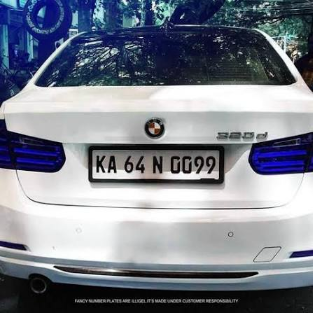

In [44]:
image

In [45]:
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

array([[128, 153, 191, ...,  32,  41,  44],
       [ 86, 123, 176, ...,  53,  44,  52],
       [138, 131, 142, ...,  83,  94, 119],
       ...,
       [ 34,  33,  31, ...,  31,  33,  32],
       [ 26,  26,  26, ...,  28,  31,  32],
       [ 21,  23,  24, ...,  31,  31,  29]], dtype=uint8)
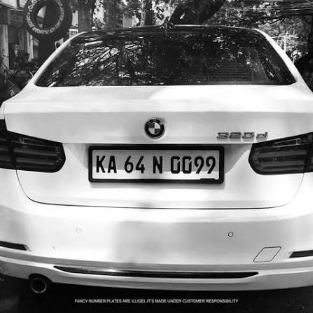

In [46]:
gray

In [47]:
gray = cv2.bilateralFilter(gray, 11, 17, 17)

array([[128, 150, 190, ...,  45,  50,  52],
       [ 91, 124, 181, ...,  57,  51,  58],
       [135, 130, 138, ...,  79,  85, 100],
       ...,
       [ 32,  32,  32, ...,  31,  31,  31],
       [ 31,  31,  31, ...,  31,  31,  32],
       [ 30,  30,  30, ...,  31,  31,  32]], dtype=uint8)
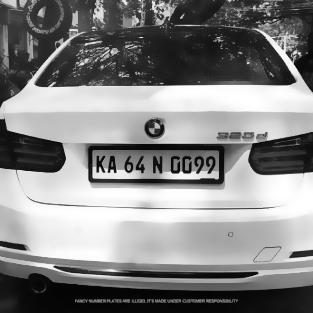

In [48]:
gray

In [49]:
edges = cv2.Canny(gray, 30, 200)

array([[255, 255,   0, ...,   0,   0, 255],
       [  0,   0, 255, ..., 255, 255, 255],
       [  0,   0,   0, ...,   0,   0,   0],
       ...,
       [  0,   0,   0, ...,   0,   0,   0],
       [  0,   0,   0, ...,   0,   0,   0],
       [  0,   0,   0, ...,   0,   0,   0]], dtype=uint8)
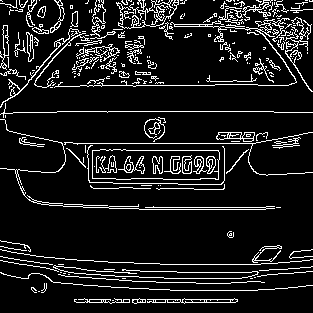

In [50]:
edges

In [51]:
# Find contours
contours, _ = cv2.findContours(
    edges.copy(),
    cv2.RETR_TREE,
    cv2.CHAIN_APPROX_SIMPLE
)

In [52]:
contours

(array([[[112, 300]],
 
        [[113, 300]]], dtype=int32),
 array([[[184, 298]],
 
        [[183, 299]],
 
        [[182, 299]],
 
        [[182, 301]],
 
        [[181, 302]],
 
        [[180, 301]],
 
        [[180, 299]],
 
        [[147, 299]],
 
        [[152, 299]],
 
        [[153, 300]],
 
        [[153, 301]],
 
        [[152, 302]],
 
        [[151, 301]],
 
        [[149, 301]],
 
        [[148, 302]],
 
        [[147, 301]],
 
        [[147, 302]],
 
        [[149, 302]],
 
        [[150, 301]],
 
        [[151, 301]],
 
        [[152, 302]],
 
        [[165, 302]],
 
        [[165, 300]],
 
        [[166, 299]],
 
        [[167, 300]],
 
        [[167, 302]],
 
        [[179, 302]],
 
        [[180, 301]],
 
        [[181, 302]],
 
        [[183, 302]],
 
        [[184, 303]],
 
        [[185, 302]],
 
        [[235, 302]],
 
        [[236, 301]],
 
        [[237, 301]],
 
        [[237, 299]],
 
        [[235, 299]],
 
        [[234, 298]],
 
        [[233, 299]],
 
   

In [53]:
# Keep the largest contours
contours = sorted(
    contours,
    key=cv2.contourArea,
    reverse=True
)[:30]

In [54]:
contours

[array([[[100, 149]],
 
        [[ 99, 150]],
 
        [[ 92, 150]],
 
        [[ 92, 178]],
 
        [[115, 178]],
 
        [[116, 179]],
 
        [[130, 179]],
 
        [[131, 178]],
 
        [[162, 178]],
 
        [[163, 179]],
 
        [[200, 179]],
 
        [[201, 178]],
 
        [[214, 178]],
 
        [[215, 179]],
 
        [[218, 179]],
 
        [[218, 160]],
 
        [[219, 159]],
 
        [[219, 152]],
 
        [[218, 151]],
 
        [[218, 150]],
 
        [[126, 150]],
 
        [[125, 149]],
 
        [[123, 149]],
 
        [[122, 150]],
 
        [[121, 150]],
 
        [[120, 149]],
 
        [[113, 149]],
 
        [[112, 150]],
 
        [[111, 150]],
 
        [[110, 149]],
 
        [[109, 149]],
 
        [[108, 150]],
 
        [[106, 150]],
 
        [[105, 149]]], dtype=int32),
 array([[[ 99, 150]],
 
        [[100, 149]],
 
        [[105, 149]],
 
        [[106, 150]],
 
        [[108, 150]],
 
        [[109, 149]],
 
        [[110, 149]],
 
   

Detected licence plate: KA 64 N 0G22


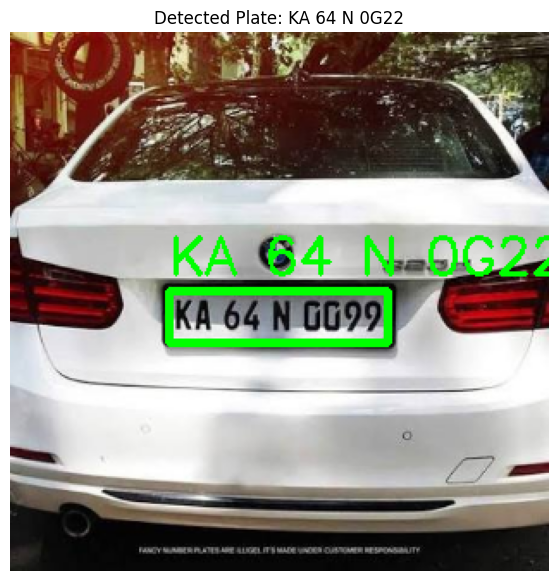

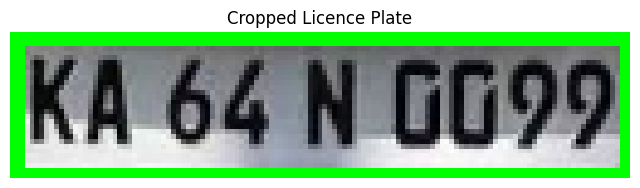

In [56]:
plate_contour = None

# Search for a rectangular contour
for contour in contours:

    perimeter = cv2.arcLength(
        contour,
        True
    )

    approximate_shape = cv2.approxPolyDP(
        contour,
        0.02 * perimeter,  # Reverted epsilon to original value
        True
    )

    # Licence plates are usually rectangular
    if len(approximate_shape) == 4:
        # Get bounding box of the contour
        x, y, w, h = cv2.boundingRect(approximate_shape)
        aspect_ratio = float(w) / h

        # Check if the aspect ratio is within a typical range for license plates
        # (e.g., between 2.0 and 6.0) and if the area is not too small.
        if 2.0 < aspect_ratio < 6.0 and w * h > 2000:
            plate_contour = approximate_shape
            break


if plate_contour is None:
    print("Licence plate was not detected.")

else:
    # Get plate position
    x, y, width, height = cv2.boundingRect(
        plate_contour
    )

    # Crop licence plate
    plate_image = image[
        y:y + height,
        x:x + width
    ]

    # Create EasyOCR reader
    reader = easyocr.Reader(
        ["en"],
        gpu=False
    )

    # Extract text
    results = reader.readtext(
        plate_image,
        detail=0
    )

    plate_number = " ".join(results)

    print("Detected licence plate:", plate_number)


    # Draw plate box
    cv2.rectangle(
        image,
        (x, y),
        (x + width, y + height),
        (0, 255, 0),
        3
    )


    # Draw plate number
    cv2.putText(
        image,
        plate_number,
        (x, max(30, y - 10)),
        cv2.FONT_HERSHEY_SIMPLEX,
        1,
        (0, 255, 0),
        2
    )


    # Convert images from BGR to RGB
    result_rgb = cv2.cvtColor(
        image,
        cv2.COLOR_BGR2RGB
    )

    plate_rgb = cv2.cvtColor(
        plate_image,
        cv2.COLOR_BGR2RGB
    )


    # Display detected result
    plt.figure(figsize=(12, 7))
    plt.imshow(result_rgb)
    plt.axis("off")
    plt.title(f"Detected Plate: {plate_number}")
    plt.show()


    # Display cropped plate
    plt.figure(figsize=(8, 3))
    plt.imshow(plate_rgb)
    plt.axis("off")
    plt.title("Cropped Licence Plate")
    plt.show()